# ICLR Results

Plots the W&B groups tagged `ICLR`, using log paths relative to the `MyExpoComm` working directory.
Adversarial Pursuit retains its original aggregation; Battle aligns seeds to a common timestep grid before averaging, as described below.


# Adversarial Pursuit

The plotting function below is the adversarial-pursuit function from `reproduce_results.ipynb`.

In [1]:
import re
import os
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

def parse_group_logs_advP(file_paths):
    aggregated_data = defaultdict(list)
    t_env_pattern = re.compile(r"Recent Stats \| t_env:\s*(\d+)")
    test_return_pattern = re.compile(r"test_return_mean:\s*(-?\d+\.?\d*)")

    for path in file_paths:
        if not os.path.exists(path):
            print(f"Warning: File not found at {path}. Skipping from group configuration.")
            continue
        current_t_env = None
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                if "Recent Stats | t_env:" in line:
                    t_match = t_env_pattern.search(line)
                    if t_match:
                        current_t_env = int(t_match.group(1))
                if current_t_env is not None and "test_return_mean:" in line:
                    r_match = test_return_pattern.search(line)
                    if r_match:
                        aggregated_data[current_t_env].append(float(r_match.group(1)))
                        current_t_env = None

    sorted_timesteps = sorted(aggregated_data)
    means = [np.mean(aggregated_data[t]) for t in sorted_timesteps]
    mins = [np.min(aggregated_data[t]) for t in sorted_timesteps]
    maxes = [np.max(aggregated_data[t]) for t in sorted_timesteps]
    return sorted_timesteps, np.array(means), np.array(mins), np.array(maxes)

def plot_multi_group_performance_advP(groups_data, plot_title="Mean Test Return"):
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(11, 6.5))
    colors = ["#FF0000", "#0000FF", "#137333"]

    for idx, (group_name, paths) in enumerate(groups_data.items()):
        steps, y_mean, y_min, y_max = parse_group_logs_advP(paths)
        if not steps:
            print(f"Skipping plot for group '{group_name}' due to missing data.")
            continue
        color = colors[idx % len(colors)]
        num_runs = len(paths)
        if num_runs > 1:
            ax.fill_between(steps, y_min, y_max, color=color, alpha=0.15,
                            label=f"{group_name} Range (Min/Max)")
        ax.plot(steps, y_mean, color=color, linewidth=2.5,
                label=f"{group_name} Mean ({num_runs} runs)")

    ax.set_title(plot_title, fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Timestep", fontsize=11, labelpad=10)
    ax.set_ylabel("Mean Test Return", fontsize=11, labelpad=10)
    ax.ticklabel_format(style="scientific", scilimits=(0, 0), axis="x")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(frameon=True, facecolor="white", edgecolor="none", loc="best")
    plt.tight_layout()
    plt.show()

In [2]:
ADVP_EXPOCOMM = [
    "logs/advP_EC_op_nomm_42_2143352.err",
    "logs/advP_EC_op_nomm_43_2143358.err",
    "logs/advP_EC_op_nomm_44_2143362.err",
]
ADVP_HYBRIDCOMM = [
    "logs/advP_HC_op_nomm_42_2143357.err",
    "logs/advP_HC_op_nomm_43_2143359.err",
    "logs/advP_HC_op_nomm_44_2143363.err",
]
ADVP_IQL_RNN = [
    "logs/advP_IQL_RNN_nomm_42_2143355.err",
    "logs/advP_IQL_RNN_nomm_43_2143360.err",
    "logs/advP_IQL_RNN_nomm_44_2143364.err",
]
ADVP_BIG_EXPOCOMM = [
    "logs/advP_B_EC_op_nomm_42_2147127.err",
    "logs/advP_B_EC_op_nomm_43_2147130.err",
    "logs/advP_B_EC_op_nomm_44_2147133.err",
]
ADVP_BIG_HYBRIDCOMM = [
    "logs/advP_B_HC_op_nomm_42_2147128.err",
    "logs/advP_B_HC_op_nomm_43_2147131.err",
    "logs/advP_B_HC_op_nomm_44_2147134.err",
]
ADVP_BIG_IQL_RNN = [
    "logs/advP_B_IQL_RNN_nomm_42_2147129.err",
    "logs/advP_B_IQL_RNN_nomm_43_2147132.err",
    "logs/advP_B_IQL_RNN_nomm_44_2147135.err",
]
ADVP_EXPOCOMM_STATIC = [
    "logs/advP_EC_st_nomm_42_2214582.err",
    "logs/advP_EC_st_nomm_43_2214584.err",
    "logs/advP_EC_st_nomm_44_2214586.err",
]
ADVP_HYBRIDCOMM_STATIC = [
    "logs/advP_HC_st_nomm_42_2213112.err",
    "logs/advP_HC_st_nomm_43_2213113.err",
    "logs/advP_HC_st_nomm_44_2213114.err",
]
ADVP_BIG_EXPOCOMM_STATIC = [
    "logs/advP_B_EC_st_nomm_42_2214587.err",
    "logs/advP_B_EC_st_nomm_43_2214588.err",
    "logs/advP_B_EC_st_nomm_44_2214589.err",
]
ADVP_BIG_HYBRIDCOMM_STATIC = [
    "logs/advP_B_HC_st_nomm_42_2213115.err",
    "logs/advP_B_HC_st_nomm_43_2213116.err",
    "logs/advP_B_HC_st_nomm_44_2213117.err",
]

ADV_PURSUIT = {"ExpoComm": ADVP_EXPOCOMM, "HybridComm": ADVP_HYBRIDCOMM, "IQL with RNN": ADVP_IQL_RNN}
ADV_PURSUIT_BIG = {"ExpoComm": ADVP_BIG_EXPOCOMM, "HybridComm": ADVP_BIG_HYBRIDCOMM, "IQL with RNN": ADVP_BIG_IQL_RNN}
ADV_PURSUIT_STATIC = {"ExpoComm Static": ADVP_EXPOCOMM_STATIC, "HybridComm Static": ADVP_HYBRIDCOMM_STATIC, "IQL with RNN": ADVP_IQL_RNN}
ADV_PURSUIT_BIG_STATIC = {"ExpoComm Static": ADVP_BIG_EXPOCOMM_STATIC, "HybridComm Static": ADVP_BIG_HYBRIDCOMM_STATIC, "IQL with RNN": ADVP_BIG_IQL_RNN}

## 1. Adversarial Pursuit

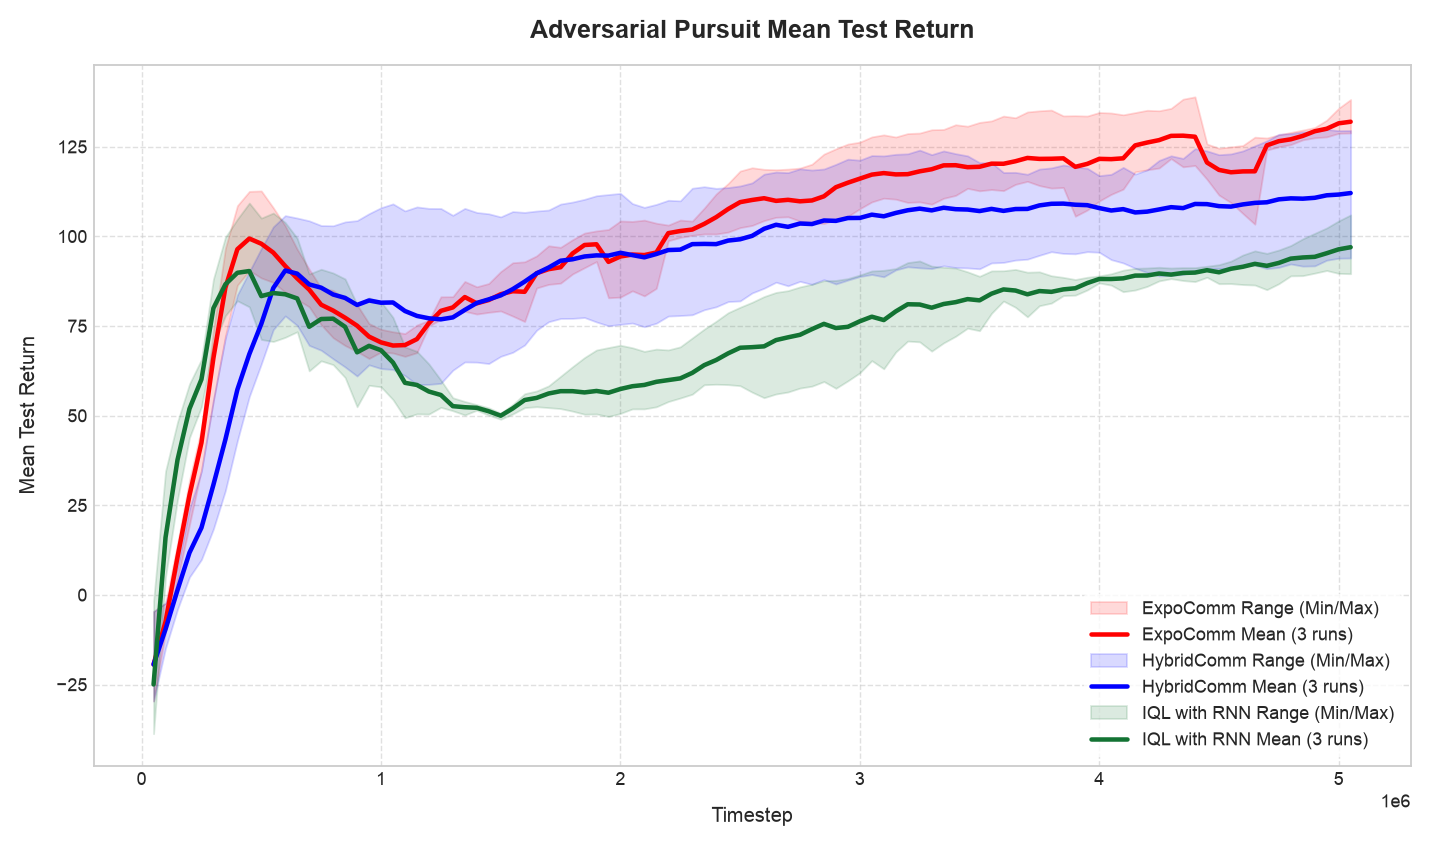

In [3]:
plot_multi_group_performance_advP(ADV_PURSUIT, "Adversarial Pursuit Mean Test Return")

## 2. Adversarial Pursuit, Big

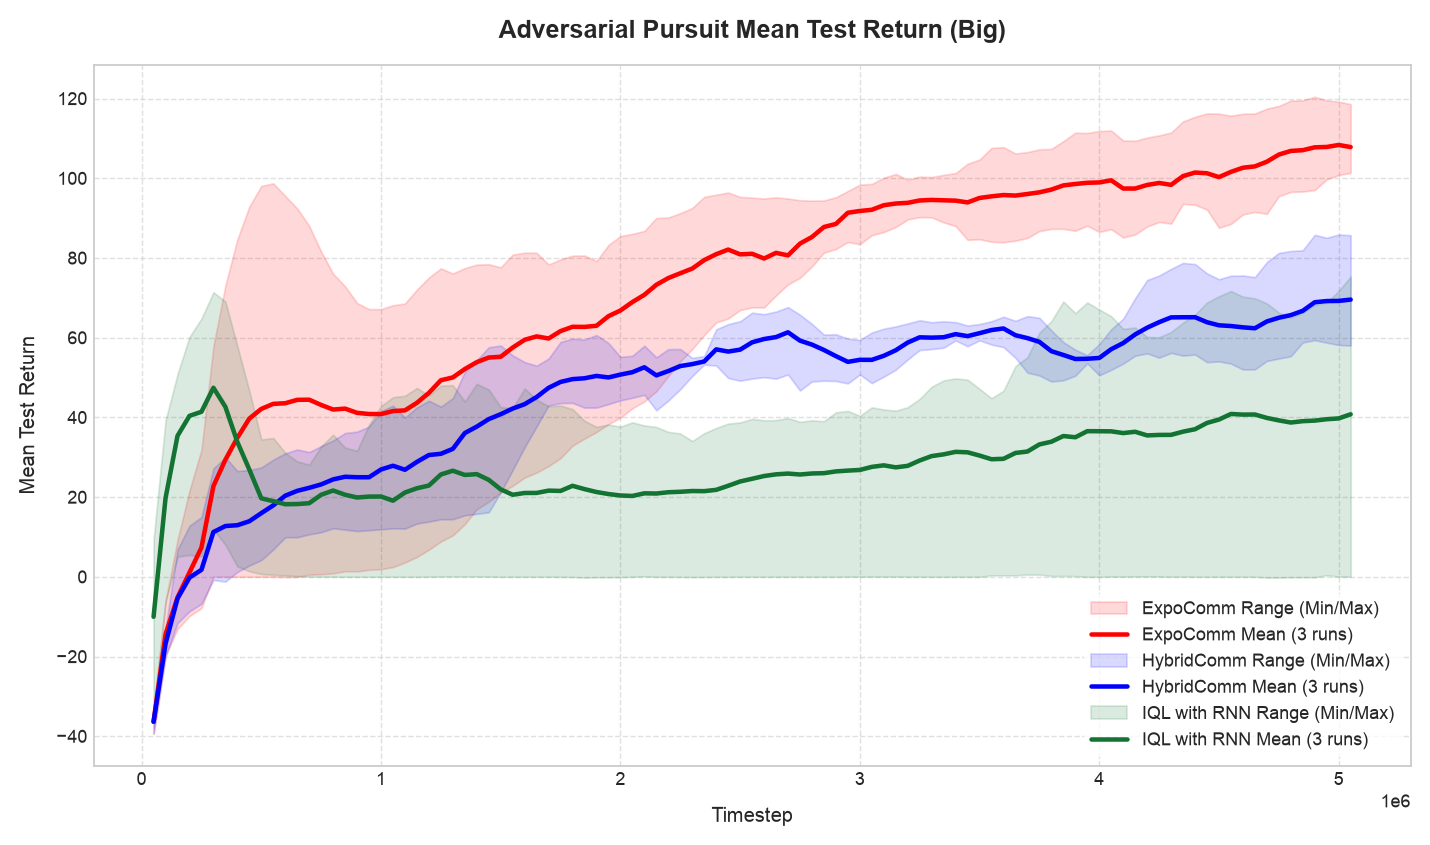

In [4]:
plot_multi_group_performance_advP(ADV_PURSUIT_BIG, "Adversarial Pursuit Mean Test Return (Big)")

## 3. Adversarial Pursuit, Static

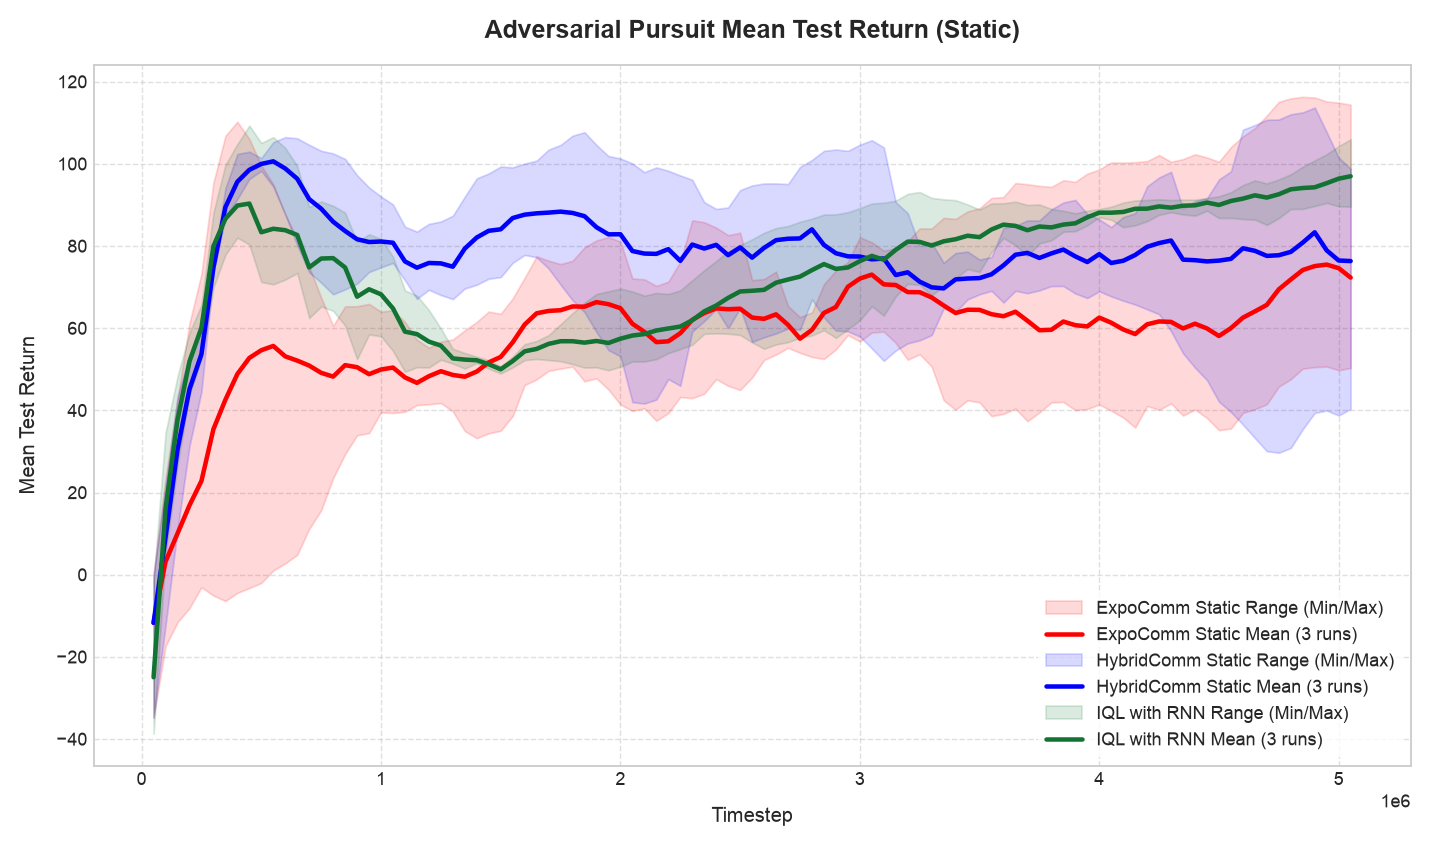

In [5]:
plot_multi_group_performance_advP(ADV_PURSUIT_STATIC, "Adversarial Pursuit Mean Test Return (Static)")

## 4. Adversarial Pursuit, Big Static

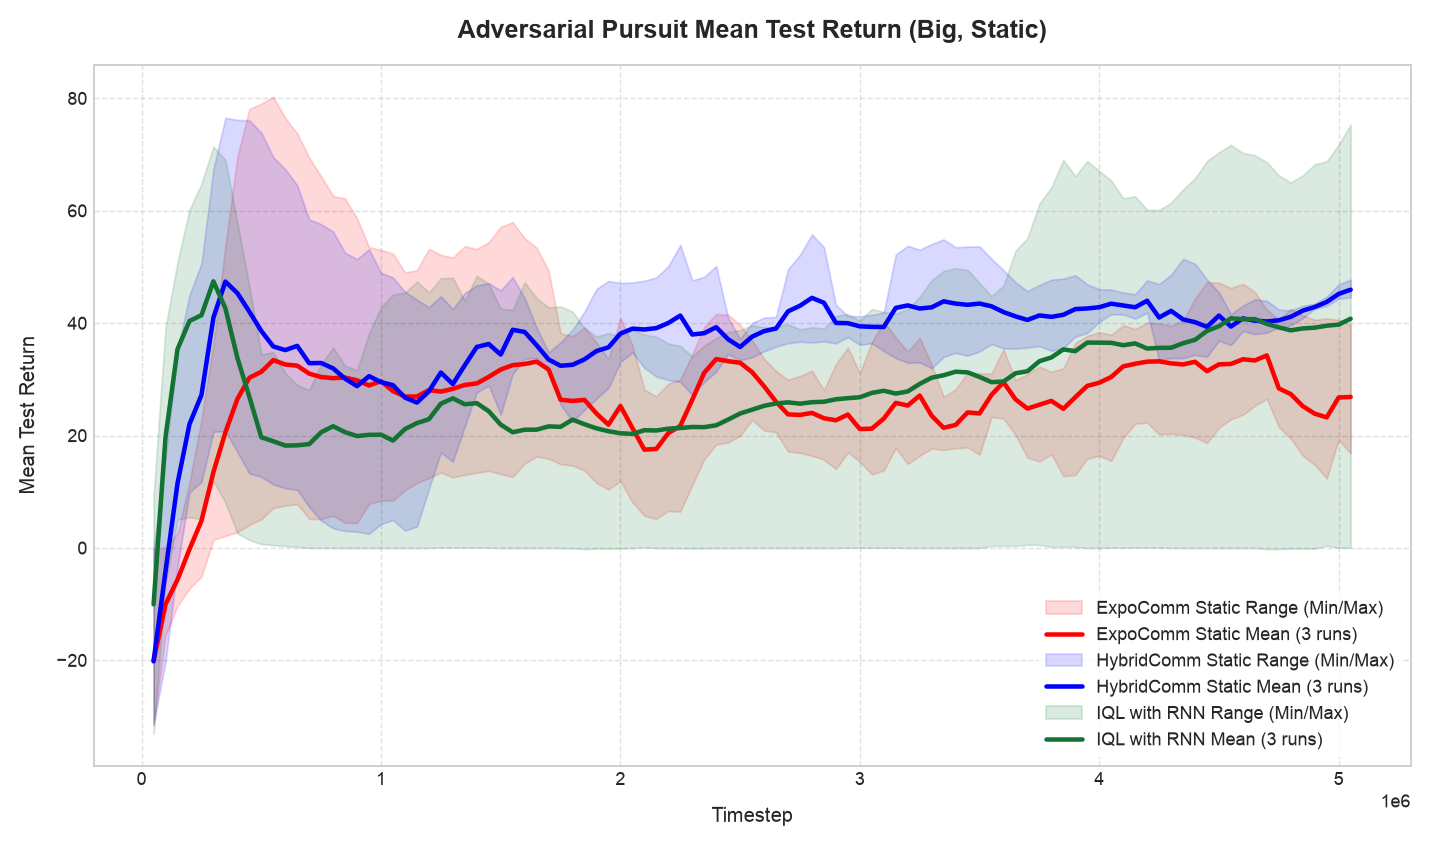

In [6]:
plot_multi_group_performance_advP(ADV_PURSUIT_BIG_STATIC, "Adversarial Pursuit Mean Test Return (Big, Static)")

# Battle

Each log is one training seed. All seeds and algorithms in a figure are linearly interpolated onto a shared 50,000-environment-step grid, restricted to their overlapping recorded time range (no extrapolation). Each seed has equal weight at every plotted step.

For display, each aligned seed curve is exponentially smoothed with coefficient 0.85. Lines show the mean of these curves and shading shows their min/max range, **not a confidence interval**. Numerical endpoint comparisons should use the unsmoothed aligned returns.

The Battle 60 n9 groups include all five seeds (42–46) for each communication method. Standard Battle uses the existing five-seed one-peer groups; no standard-Battle n9 runs were added.


In [7]:
def exponential_moving_average(values, coefficient=0.85):
    values = np.atleast_1d(np.asarray(values, dtype=np.float64))
    if len(values) == 0:
        return np.array([])
    smoothed = []
    last = values[0]
    for point in values:
        smoothed_val = (last * coefficient) + (point * (1 - coefficient))
        smoothed.append(smoothed_val)
        last = smoothed_val
    return np.array(smoothed)

def parse_battle_logs(file_paths):
    """Read one return series per seed; fail rather than silently omit a run."""
    if len(set(file_paths)) != len(file_paths):
        raise ValueError("Duplicate log paths would give a seed extra weight")
    runs = []
    for path in file_paths:
        points = []
        current_step = None
        with open(path, encoding="utf-8") as log:
            for line in log:
                match = re.search(r"Recent Stats \| t_env:\s*(\d+)", line)
                if match:
                    current_step = int(match.group(1))
                match = re.search(r"test_return_mean:\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", line)
                if current_step is not None and match:
                    points.append((current_step, float(match.group(1))))
                    current_step = None
        if not points:
            raise ValueError(f"No test returns in {path}")
        steps, values = np.asarray(points, dtype=float).T
        if np.any(np.diff(steps) <= 0) or not np.all(np.isfinite(values)):
            raise ValueError(f"Invalid or repeated timesteps/returns in {path}")
        runs.append((steps, values))
    return runs

def align_battle_runs(runs, interval=50_000):
    """Interpolate all seeds on the same grid, without endpoint extrapolation."""
    if not runs or interval <= 0:
        raise ValueError("Runs and a positive evaluation interval are required")
    start = int(np.ceil(max(steps[0] for steps, _ in runs) / interval)) * interval
    end = int(np.floor(min(steps[-1] for steps, _ in runs) / interval)) * interval
    if start > end:
        raise ValueError("Runs have no common evaluation grid")
    grid = np.arange(start, end + 1, interval)
    returns = np.vstack([np.interp(grid, steps, values) for steps, values in runs])
    return grid, returns

def plot_multi_group_performance_battle(groups_data, plot_title="Mean Test Return", smoothing_coeff=0.85):
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(11, 6.5))
    colors = ["#FF0000", "#0000FF", "#137333"]
    groups = {name: parse_battle_logs(paths) for name, paths in groups_data.items()}
    steps, aligned = align_battle_runs([run for runs in groups.values() for run in runs])

    offset = 0
    for idx, (group_name, runs) in enumerate(groups.items()):
        num_runs = len(runs)
        values = aligned[offset:offset + num_runs]
        offset += num_runs
        smoothed = np.vstack([exponential_moving_average(row, smoothing_coeff) for row in values])
        color = colors[idx % len(colors)]
        ax.fill_between(steps, smoothed.min(axis=0), smoothed.max(axis=0), color=color, alpha=0.12)
        ax.plot(steps, smoothed.mean(axis=0), color=color, linewidth=2.5,
                label=f"{group_name} ({num_runs} seeds)")

    ax.set_title(plot_title, fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Environment timestep", fontsize=11, labelpad=10)
    ax.set_ylabel(f"Mean test return (EMA coefficient = {smoothing_coeff:g})", fontsize=11, labelpad=10)
    ax.ticklabel_format(style="scientific", scilimits=(0, 0), axis="x")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(frameon=True, facecolor="white", edgecolor="none", loc="best")
    fig.text(0.5, 0.015, "Equal weight per seed on a shared 50,000-step grid; shading: smoothed seed min/max, not a confidence interval.",
             ha="center", fontsize=9)
    plt.tight_layout(rect=(0, 0.035, 1, 1))
    plt.show()

# Regression check: irregular evaluation times retain equal seed weights,
# and the common grid cannot extend beyond either run's measurements.
_grid, _returns = align_battle_runs([
    (np.array([0, 50_000, 100_000, 150_000]), np.array([0., 0., 0., 0.])),
    (np.array([25_000, 75_000, 125_000]), np.array([10., 20., 30.])),
])
np.testing.assert_array_equal(_grid, [50_000, 100_000])
np.testing.assert_allclose(_returns, [[0., 0.], [15., 25.]])
np.testing.assert_allclose(_returns.mean(axis=0), [7.5, 12.5])
del _grid, _returns


In [8]:
BATTLE_EXPOCOMM = [
    "logs/bat_ExpoComm_5M_original_rewards_1870522.err",
    "logs/bat_ExpoComm_5M_43_1871349.err",
    "logs/bat_ExpoComm_5M_44_1873123.err",
    "logs/bat_ExpoComm_5M_45_1874978.err",
    "logs/bat_ExpoComm_5M_46_1882050.err",
]
BATTLE_HYBRIDCOMM = [
    "logs/bat_HybridComm_5M_original_rewards_1870524.err",
    "logs/bat_HybridComm_5M_43_1871351.err",
    "logs/bat_HybridComm_5M_44_1874951.err",
    "logs/bat_HybridComm_5M_45_1874979.err",
    "logs/bat_HybridComm_5M_46_1882051.err",
]
BATTLE_IQL_RNN = [
    "logs/bat_IQL_RNN_5M_original_rewards_1870526.err",
    "logs/bat_IQL_RNN_5M_43_1871352.err",
    "logs/bat_IQL_RNN_5M_44_1874953.err",
    "logs/bat_IQL_RNN_5M_45_1874981.err",
    "logs/bat_IQL_RNN_5M_46_1882052.err",
]
BATTLE_60_EXPOCOMM = [
    "logs/bat_60_ExpoComm_5M_42_1872728.err",
    "logs/bat_60_ExpoComm_5M_43_1897904.err",
    "logs/bat_60_ExpoComm_5M_44_1887238.err",
    "logs/bat_60_ExpoComm_5M_45_1895082.err",
    "logs/bat_60_ExpoComm_5M_46_1897870.err",
]
BATTLE_60_HYBRIDCOMM = [
    "logs/bat_60_HybridComm_5M_42_1872729.err",
    "logs/bat_60_HybridComm_5M_43_1874997.err",
    "logs/bat_60_HybridComm_5M_44_1882096.err",
    "logs/bat_60_HybridComm_5M_45_1895084.err",
    "logs/bat_60_HybridComm_5M_46_1897871.err",
]
BATTLE_60_IQL_RNN = [
    "logs/bat_60_IQL_RNN_5M_42_1872730.err",
    "logs/bat_60_IQL_RNN_5M_43_1874999.err",
    "logs/bat_60_IQL_RNN_5M_44_1882097.err",
    "logs/bat_60_IQL_RNN_5M_45_1895086.err",
    "logs/bat_60_IQL_RNN_5M_46_1897859.err",
]
BATTLE_60_EXPOCOMM_N9 = [
    "logs/bat_60_ExpoComm_n9_42_2233055.err",
    "logs/bat_60_ExpoComm_n9_43_2233056.err",
    "logs/bat_60_ExpoComm_n9_44_2246620.err",
    "logs/bat_60_ExpoComm_n9_45_2246621.err",
    "logs/bat_60_ExpoComm_n9_46_2246624.err",
]
BATTLE_60_HYBRIDCOMM_N9 = [
    "logs/bat_60_HybridComm_n9_42_2233057.err",
    "logs/bat_60_HybridComm_n9_43_2233058.err",
    "logs/bat_60_HybridComm_n9_44_2246622.err",
    "logs/bat_60_HybridComm_n9_45_2246623.err",
    "logs/bat_60_HybridComm_n9_46_2246625.err",
]
BATTLE_EXPOCOMM_STATIC = [
    "logs/bat_ExpoComm_static_42_2218606.err",
    "logs/bat_ExpoComm_static_43_2218607.err",
    "logs/bat_ExpoComm_static_44_2218609.err",
    "logs/bat_ExpoComm_static_45_2218610.err",
    "logs/bat_ExpoComm_static_46_2218611.err",
]
BATTLE_HYBRIDCOMM_STATIC = [
    "logs/bat_HybridComm_static_42_2090694.err",
    "logs/bat_HybridComm_static_43_2093588.err",
    "logs/bat_HybridComm_static_44_2167415.err",
    "logs/bat_HybridComm_static_45_2203240.err",
    "logs/bat_HybridComm_static_46_2203242.err",
]
BATTLE_60_EXPOCOMM_STATIC = [
    "logs/bat_60_ExpoComm_static_42_2219257.err",
    "logs/bat_60_ExpoComm_static_43_2219240.err",
    "logs/bat_60_ExpoComm_static_44_2219241.err",
    "logs/bat_60_ExpoComm_static_45_2219242.err",
    "logs/bat_60_ExpoComm_static_46_2219243.err",
]
BATTLE_60_HYBRIDCOMM_STATIC = [
    "logs/bat_60_HybridComm_static_42_2090703.err",
    "logs/bat_60_HybridComm_static_43_2093590.err",
    "logs/bat_60_HybridComm_static_44_2167417.err",
    "logs/bat_60_HybridComm_static_45_2203246.err",
    "logs/bat_60_HybridComm_static_46_2203248.err",
]

BATTLE = {"ExpoComm": BATTLE_EXPOCOMM, "HybridComm": BATTLE_HYBRIDCOMM, "IQL with RNN": BATTLE_IQL_RNN}
BATTLE_60 = {"ExpoComm": BATTLE_60_EXPOCOMM, "HybridComm": BATTLE_60_HYBRIDCOMM, "IQL with RNN": BATTLE_60_IQL_RNN}
BATTLE_60_N9 = {"ExpoComm n9": BATTLE_60_EXPOCOMM_N9, "HybridComm n9": BATTLE_60_HYBRIDCOMM_N9, "IQL with RNN": BATTLE_60_IQL_RNN}
BATTLE_STATIC = {"ExpoComm Static": BATTLE_EXPOCOMM_STATIC, "HybridComm Static": BATTLE_HYBRIDCOMM_STATIC, "IQL with RNN": BATTLE_IQL_RNN}
BATTLE_60_STATIC = {"ExpoComm Static": BATTLE_60_EXPOCOMM_STATIC, "HybridComm Static": BATTLE_60_HYBRIDCOMM_STATIC, "IQL with RNN": BATTLE_60_IQL_RNN}

## 5. Battle

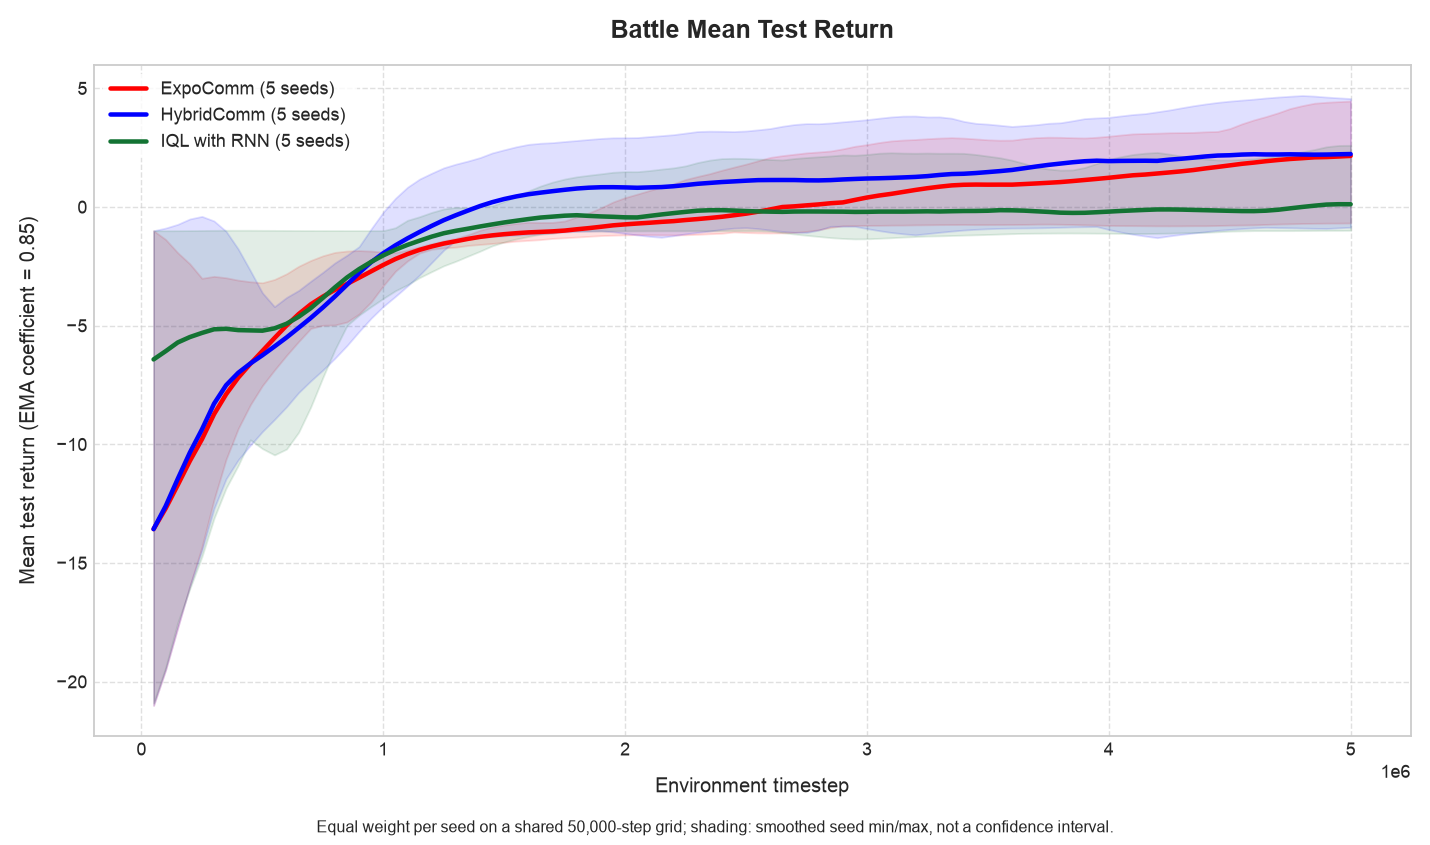

In [9]:
plot_multi_group_performance_battle(BATTLE, "Battle Mean Test Return")

## 6. Battle 60

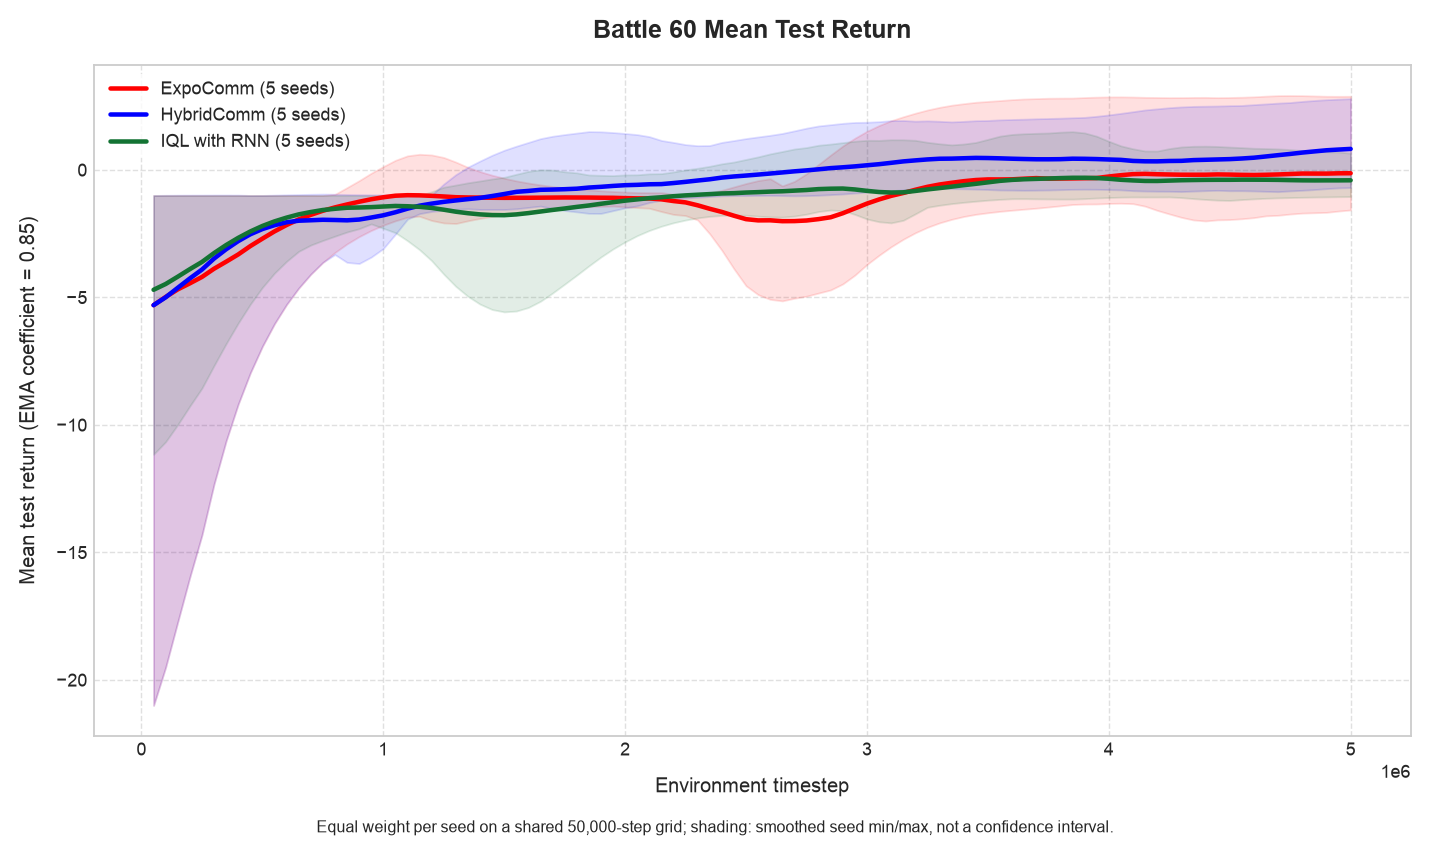

In [10]:
plot_multi_group_performance_battle(BATTLE_60, "Battle 60 Mean Test Return")

## 7. Battle 60, n9

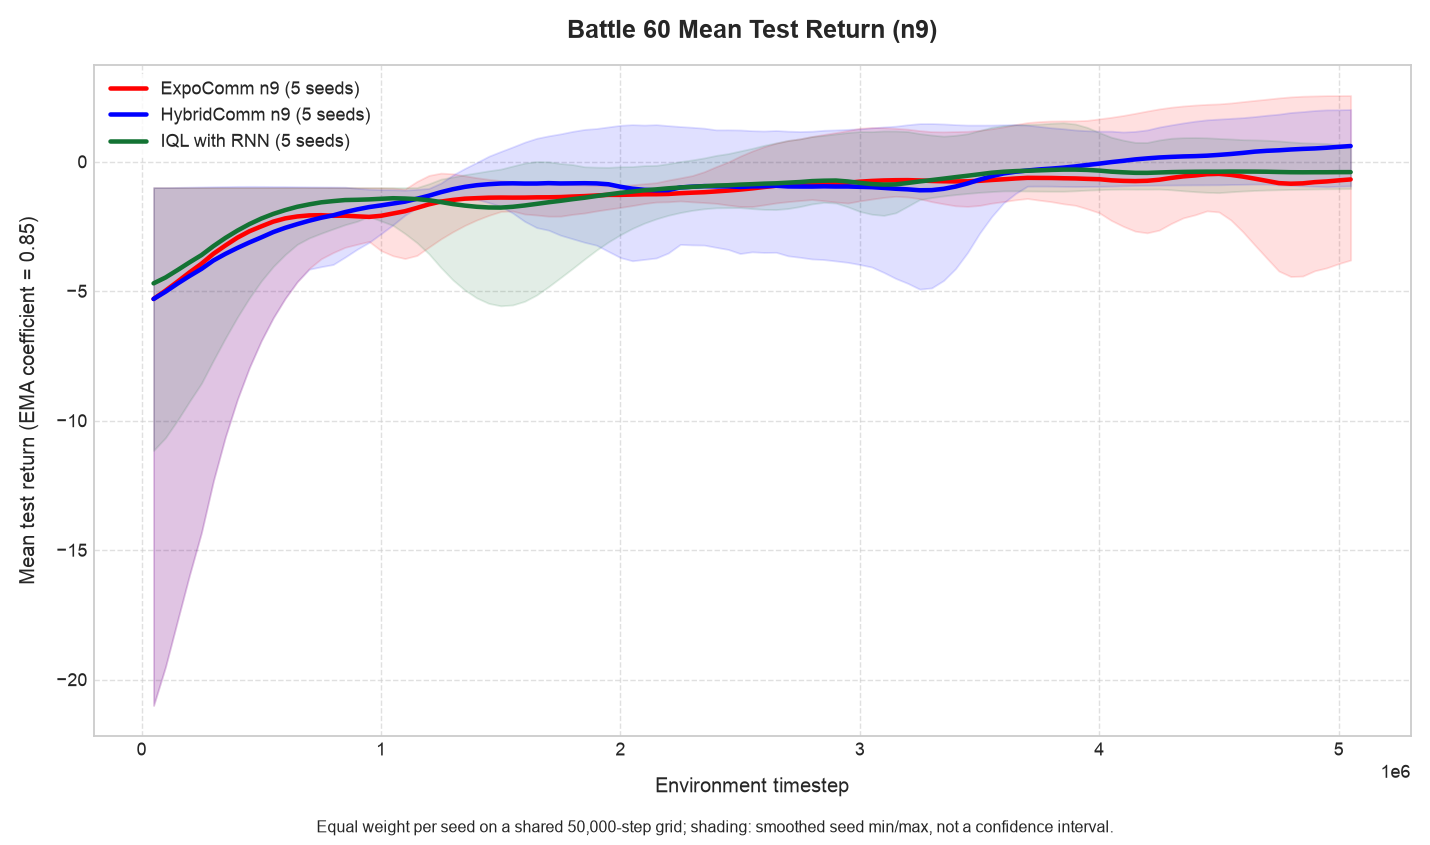

In [11]:
plot_multi_group_performance_battle(BATTLE_60_N9, "Battle 60 Mean Test Return (n9)")

## 8. Battle, Static

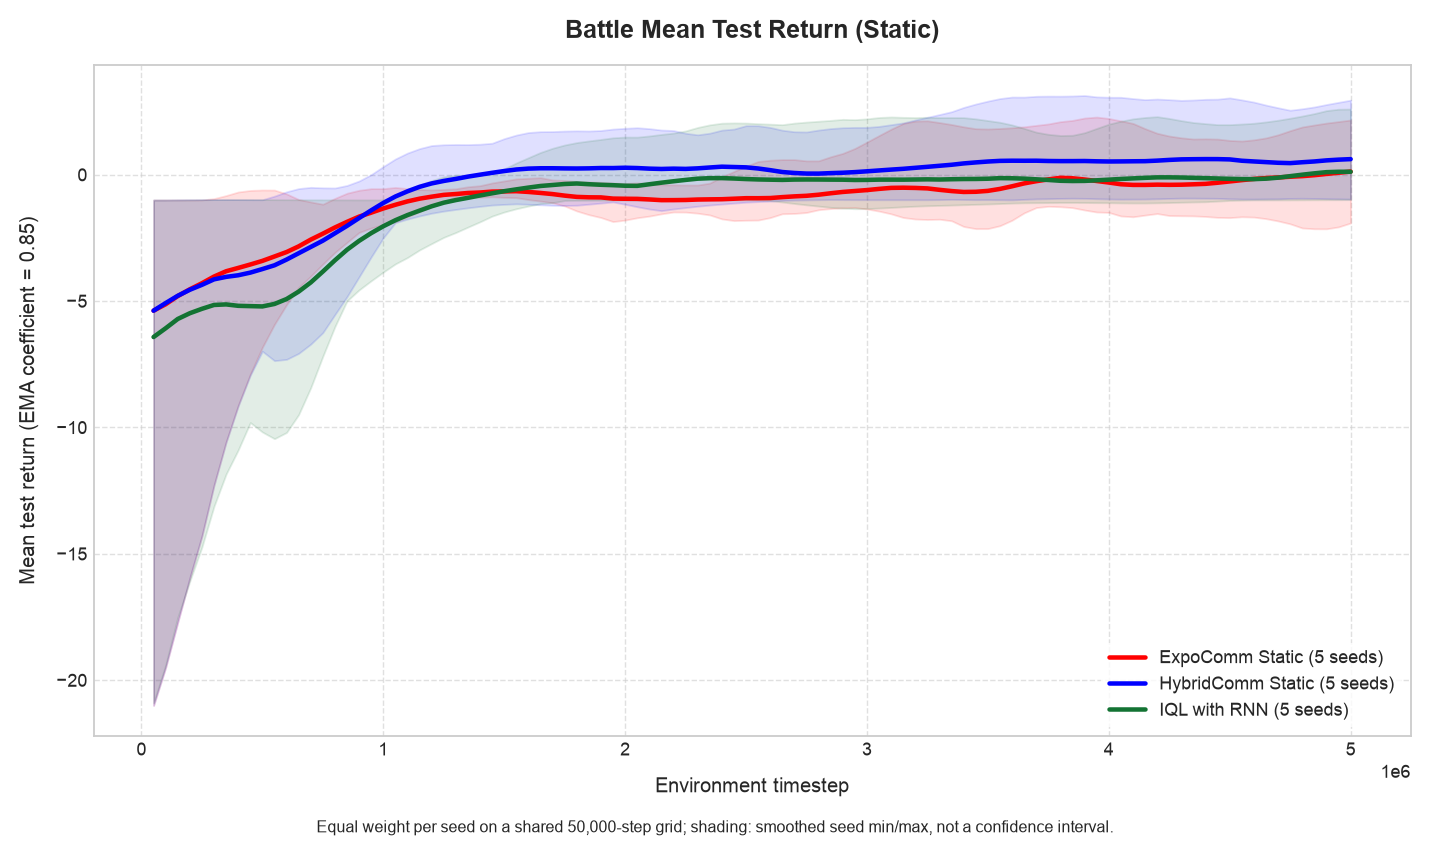

In [12]:
plot_multi_group_performance_battle(BATTLE_STATIC, "Battle Mean Test Return (Static)")

## 9. Battle 60, Static

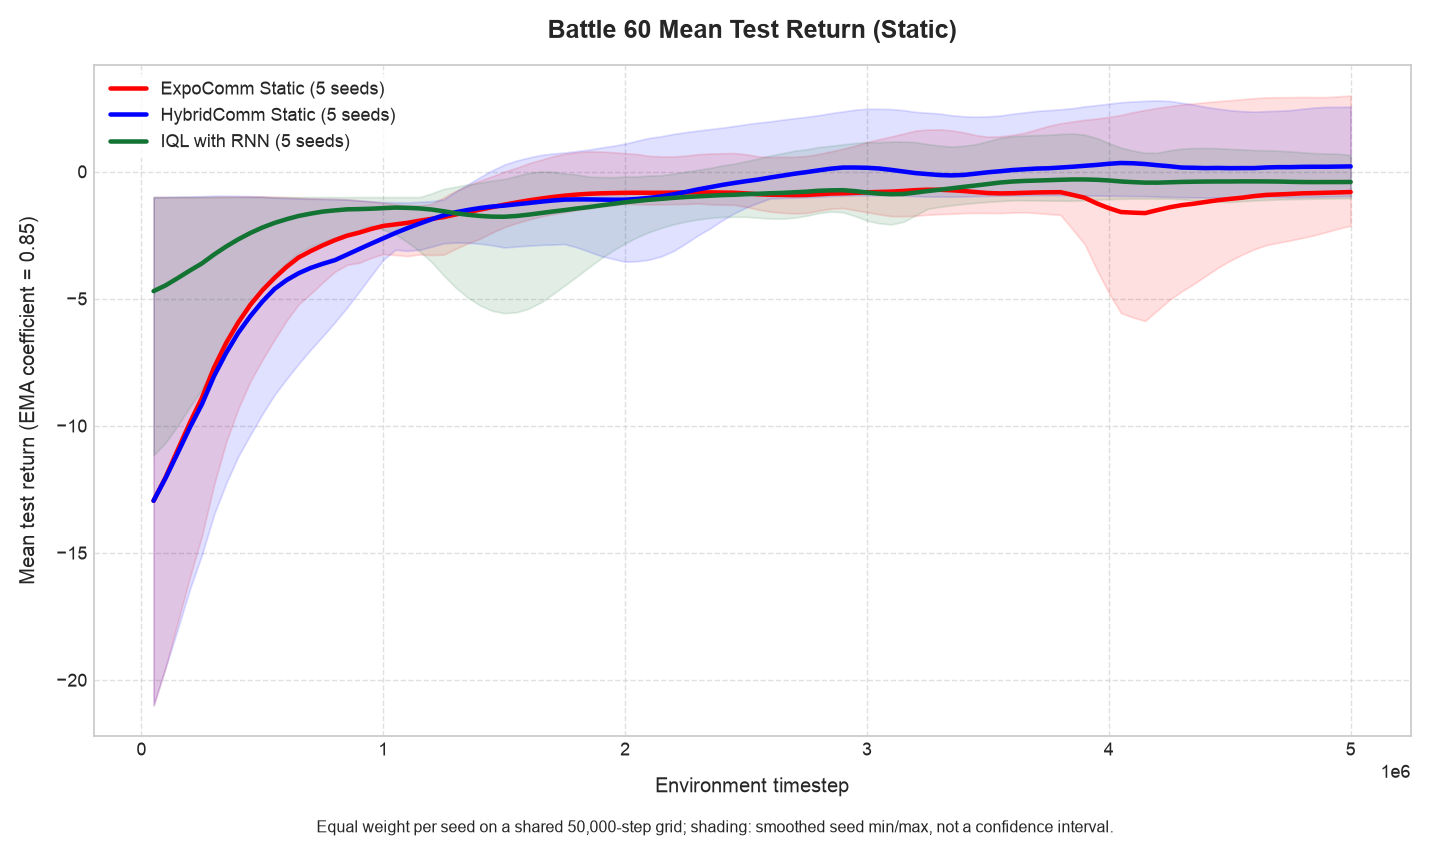

In [13]:
plot_multi_group_performance_battle(BATTLE_60_STATIC, "Battle 60 Mean Test Return (Static)")